In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## <center> Load Data

In [12]:

np.random.seed(0)
tau_true = 2.2  # microseconds
data = np.random.exponential(scale=tau_true, size=1000)


## <center>Exploratory Data Analysis

Number of samples: 1000
Mean decay time: 2.2078 microseconds
Variance: 5.1257 microseconds^2


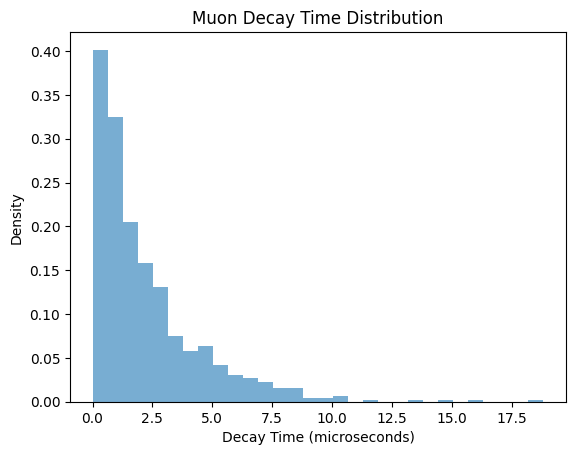

In [13]:
print("Number of samples:", len(data))
print("Mean decay time:", np.mean(data).round(4), "microseconds")
print("Variance:", np.var(data).round(4), "microseconds^2")

# Histogram
plt.hist(data, bins=30, density=True, alpha=0.6)
plt.xlabel("Decay Time (microseconds)")
plt.ylabel("Density")
plt.title("Muon Decay Time Distribution")
plt.show()

## <center> MLE

In [14]:
tau_mle = np.mean(data)
print("MLE estimate of tau:", tau_mle.round(4), "microseconds")

MLE estimate of tau: 2.2078 microseconds


## <center> Fit Exponential Curve

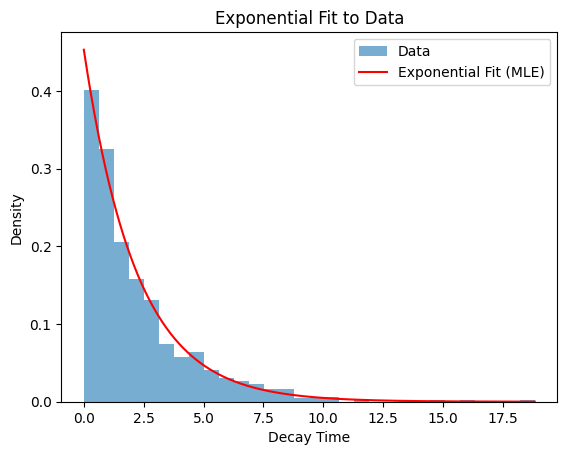

In [15]:
x = np.linspace(0, max(data), 1000)
pdf = (1/tau_mle) * np.exp(-x/tau_mle)

plt.hist(data, bins=30, density=True, alpha=0.6, label="Data")
plt.plot(x, pdf, 'r-', label="Exponential Fit (MLE)")
plt.legend()
plt.xlabel("Decay Time")
plt.ylabel("Density")
plt.title("Exponential Fit to Data")
plt.show()

## <center> Chi-Square Goodness of Fit

In [16]:
# Histogram for chi-square
counts, bin_edges = np.histogram(data, bins=30)
bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

expected = len(data) * (np.exp(-bin_edges[:-1]/tau_mle) - np.exp(-bin_edges[1:]/tau_mle))

# Avoid zero expected values
mask = expected > 0

chi2 = np.sum((counts[mask] - expected[mask])**2 / expected[mask])
dof = len(counts[mask]) - 1 - 1  # bins - parameters

p_value = 1 - stats.chi2.cdf(chi2, dof)

print("Chi-square:", chi2.round(4))
print("Degrees of freedom:", dof)
print("p-value:", p_value.round(4))

Chi-square: 37.5442
Degrees of freedom: 28
p-value: 0.1073


## <center> Kolmogorov–Smirnov Test

In [17]:
D, p_ks = stats.kstest(data, 'expon', args=(0, tau_mle))

print("K-S Statistic:", D.round(4))
print("K-S p-value:", p_ks.round(4))

K-S Statistic: 0.0293
K-S p-value: 0.3496


## <center> Confidence Interval (Analytical)

In [18]:
n = len(data)
se = tau_mle / np.sqrt(n)

ci_lower = tau_mle - 1.96 * se
ci_upper = tau_mle + 1.96 * se

print("95% Confidence Interval:", '(', ci_lower.round(4), ',', ci_upper.round(4), ')')

95% Confidence Interval: ( 2.0709 , 2.3446 )


## <center> Bootstrap Method

Bootstrap Mean: 2.2086
Bootstrap Std: 0.0706
Bootstrap 95% CI: ( 2.0699 , 2.3417 )


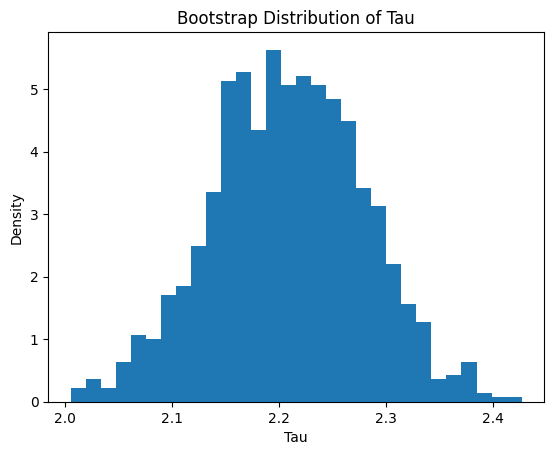

In [19]:
n_boot = 1000
tau_boot = []

for _ in range(n_boot):
    sample = np.random.choice(data, size=n, replace=True)
    tau_boot.append(np.mean(sample))

tau_boot = np.array(tau_boot)

print("Bootstrap Mean:", np.mean(tau_boot).round(4))
print("Bootstrap Std:", np.std(tau_boot).round(4))

# Confidence interval
ci_boot = np.percentile(tau_boot, [2.5, 97.5])
print("Bootstrap 95% CI:", '(', ci_boot[0].round(4), ',', ci_boot[1].round(4), ')')

# Plot
plt.hist(tau_boot, bins=30, density=True)
plt.title("Bootstrap Distribution of Tau")
plt.xlabel("Tau")
plt.ylabel("Density")
plt.show()

## <center> Model Comparison (AIC & BIC)

In [20]:
# Comparing Gaussian and Exponential Models

mu, sigma = np.mean(data), np.std(data)

# Exponential log-likelihood
logL_exp = np.sum(stats.expon.logpdf(data, scale=tau_mle))

# Gaussian log-likelihood
logL_gauss = np.sum(stats.norm.logpdf(data, loc=mu, scale=sigma))

k_exp = 1
k_gauss = 2

n = len(data)

AIC_exp = 2*k_exp - 2*logL_exp
AIC_gauss = 2*k_gauss - 2*logL_gauss

BIC_exp = k_exp*np.log(n) - 2*logL_exp
BIC_gauss = k_gauss*np.log(n) - 2*logL_gauss

print("AIC (Exponential):", AIC_exp.round(2))
print("AIC (Gaussian):", AIC_gauss.round(2))

print("BIC (Exponential):", BIC_exp.round(2))
print("BIC (Gaussian):", BIC_gauss.round(2))

AIC (Exponential): 3585.98
AIC (Gaussian): 4476.15
BIC (Exponential): 3590.89
BIC (Gaussian): 4485.96


<center>